In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.multioutput import MultiOutputClassifier, MultiOutputRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, accuracy_score, root_mean_squared_error

# Read in file 
df = pd.read_csv("../local_data/meps_clean_2014.csv")
# Rename columns if needed (e.g., handle apostrophes)
df.columns = df.columns.str.replace("'", "")
# Drop rows with NA, infinity, or other missing values
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

input_features = ["Age", "Sex", "Ethnicity", "Race", "Personal_income", "Family_income", 
                  "Poverty_category", "Cant_get_PMED", "Insurance_coverage", "PMED_insurance_coverage", "Concentration"]
output_features = ["Drug"]

input_features2 = ["Age", "Sex", "Ethnicity", "Race", "Personal_income", "Family_income", 
                  "Poverty_category", "Cant_get_PMED", "Insurance_coverage", "PMED_insurance_coverage", "Drug"]
output_features2 = ["Concentration"]

# Encode drug name
df["Drug"] = df["Drug"].astype("category").cat.codes

# Define X and y for linear/logistic regression 
X = df[input_features]
y = df[output_features]
X2 = df[input_features2]
y2 = df[output_features2]

# Train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

FileNotFoundError: [Errno 2] No such file or directory: '../local_data/meps_clean_2014.csv'

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a Logistic Regression model
log_reg = LogisticRegression(max_iter=2000, solver='lbfgs', class_weight='balanced')

# Flatten y_train and y_test
y_train_flat = y_train.values.ravel()
y_test_flat = y_test.values.ravel()

# Train the model
log_reg.fit(X_train_scaled, y_train_flat)

# Make predictions
y_pred = log_reg.predict(X_test_scaled)
y_pred_probs = log_reg.predict_proba(X_test_scaled)  # Probabilities for each category of Drug


In [7]:
# Evaluate the model using accuracy score
accuracy = accuracy_score(y_test_flat, y_pred)
print(f'Accuracy: {accuracy:.4f}')

# Optional: Confusion matrix
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(y_test_flat, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

# Precision, recall, and F1-score for each class
precision = precision_score(y_test_flat, y_pred, average='weighted', zero_division=0)  # or 'macro', 'micro'
recall = recall_score(y_test_flat, y_pred, average='weighted', zero_division=0)  # or 'macro', 'micro'
f1 = f1_score(y_test_flat, y_pred, average='weighted', zero_division=0)  # or 'macro', 'micro'

print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-score: {f1:.4f}')

# Classification report
print("\nClassification Report:")
print(classification_report(y_test_flat, y_pred, zero_division=0))


Accuracy: 0.0482
Confusion Matrix:
[[ 0  0  0 ...  0  0  0]
 [ 0 15  0 ...  0  0  0]
 [ 0  0  4 ...  0  0  0]
 ...
 [ 0  0  0 ...  1  0  0]
 [ 2  0  0 ...  0  0  1]
 [ 3  0  2 ...  0  0  0]]
Precision: 0.0626
Recall: 0.0482
F1-score: 0.0374

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.83      0.79      0.81        19
           2       0.14      0.12      0.13        32
           3       1.00      1.00      1.00         3
           4       0.03      0.67      0.06         3
           5       0.10      0.14      0.12        22
           6       0.31      0.06      0.10        66
           7       0.00      0.00      0.00        68
           8       0.02      0.09      0.04        11
           9       0.00      0.00      0.00        17
          10       0.00      0.00      0.00         0
          11       0.00      0.00      0.00        32
          12       0.00      0.0

In [182]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X2)  # Use this on your input features

# Initialize the Linear Regression model
regressor = LinearRegression()

# Train the model
regressor.fit(X_train2, y_train2)

# Predict on the test set
y_pred2 = regressor.predict(X_test2)


Mean Squared Error (MSE): 0.2759650573711662
Mean Absolute Error (MAE): 0.06708938183592303
R-squared (R2): 0.008420295019374802
Root Mean Squared Error (RMSE): 0.5253


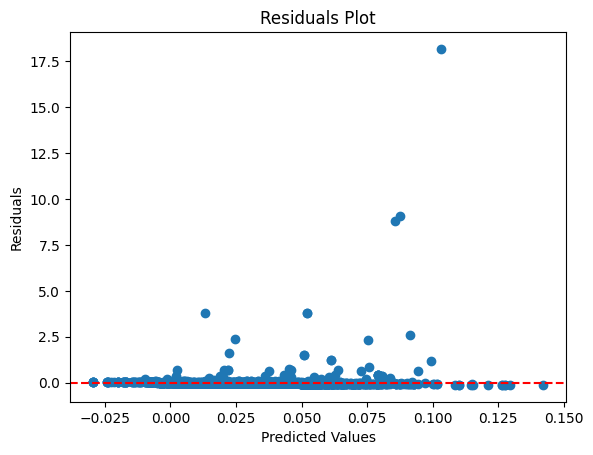

In [185]:
import matplotlib.pyplot as plt
# Evaluate the model
mse = mean_squared_error(y_test2, y_pred2)
mae = mean_absolute_error(y_test2, y_pred2)
r2 = r2_score(y_test2, y_pred2)
rmse = root_mean_squared_error(y_test2, y_pred2)

print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("R-squared (R2):", r2)
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')

residuals = y_test2 - y_pred2
plt.scatter(y_pred2, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals Plot')
plt.show()